# Network Feature Engineering with Selected Voting Dataset



In [88]:
import pandas as pd
import networkx as nx

In [89]:
votacoes_selected_df = pd.read_csv("votacoes_selected.csv")
votacoes_selected_df.head()

,id,idDeputadoAutor,legislatura,data,tema,classified_llm,authors_pop,authors_major_comm,orientacao_GOV,aprovacao
0,340896-3,74399,53,2007-02-14,Defesa e Segurança,Approval of Requests,0.0,0,Neutro,1
1,340896-3,74399,53,2007-02-14,Direito Penal e Processual Penal,Approval of Requests,0.0,0,Neutro,1
2,340368-20,74517,53,2007-02-15,"Política, Partidos e Eleições",Change in Processing Regime,0.0,1,Neutro,1
3,340368-21,74399,53,2007-02-15,"Política, Partidos e Eleições",Approval of Requests,0.0,0,Neutro,1
4,340368-31,74324,53,2007-02-15,"Política, Partidos e Eleições",Approval of Final Wording,0.0,0,Neutro,1


In [90]:
# Criar uma lista de combinações únicas de idDeputadoAutor e legislatura
unique_author_legislature = votacoes_selected_df[['idDeputadoAutor', 'legislatura']].drop_duplicates()
unique_author_legislature_list = list(unique_author_legislature.itertuples(index=False, name=None))


In [91]:
unique_author_legislature

,idDeputadoAutor,legislatura
0,74399,53
2,74517,53
4,74324,53
6,73982,53
7,73431,53
...,...,...
43092,141428,57
43093,141434,57
43094,73696,57
43098,74212,57


In [92]:
unique_author_legislature_list

[(74399, 53),
 (74517, 53),
 (74324, 53),
 (73982, 53),
 (73431, 53),
 (73666, 53),
 (74688, 53),
 (74862, 53),
 (73492, 53),
 (74295, 53),
 (74452, 53),
 (74451, 53),
 (74297, 53),
 (74063, 53),
 (74142, 53),
 (74164, 53),
 (74144, 53),
 (74061, 53),
 (74166, 53),
 (73572, 53),
 (74194, 53),
 (74028, 53),
 (74207, 53),
 (74380, 53),
 (74027, 53),
 (74211, 53),
 (74423, 53),
 (65987, 53),
 (74337, 53),
 (73507, 53),
 (74139, 53),
 (74799, 53),
 (74635, 53),
 (74579, 53),
 (74753, 53),
 (74590, 53),
 (74763, 53),
 (73817, 53),
 (73651, 53),
 (73885, 53),
 (74801, 53),
 (74286, 53),
 (74641, 53),
 (74082, 53),
 (74408, 53),
 (74756, 53),
 (74149, 53),
 (73909, 53),
 (74593, 53),
 (74150, 53),
 (73927, 53),
 (73925, 53),
 (74344, 53),
 (74349, 53),
 (73469, 53),
 (74282, 53),
 (73873, 53),
 (74675, 53),
 (74835, 53),
 (74842, 53),
 (74863, 53),
 (74259, 53),
 (74168, 53),
 (74175, 53),
 (73874, 53),
 (74176, 53),
 (74000, 53),
 (73825, 53),
 (74258, 53),
 (74097, 53),
 (73981, 53),
 (7448

In [93]:
import pickle
import os

# Verificar os arquivos que existem no diretório de grafos com comunidades
print("Verificando arquivos de grafos disponíveis...")
graphs_dir = "../../../data/graphs_with_communities/"
if os.path.exists(graphs_dir):
    files = os.listdir(graphs_dir)
    print(f"Arquivos encontrados: {files}")
else:
    print(f"Diretório {graphs_dir} não encontrado!")

# Carregar os grafos com verificações detalhadas
graphs_by_legislature = {}
for leg_id in range(52, 58):
    # Nome do arquivo verificado através do terminal: graph_legislature_XX_with_communities.gpickle
    graph_path = f"../../../data/graphs_with_communities/graph_legislature_{leg_id}_with_communities.gpickle"
    
    print(f"\nTentando carregar grafo da legislatura {leg_id}...")
    if os.path.exists(graph_path):
        try:
            with open(graph_path, "rb") as f:
                G = pickle.load(f)
            
            print(f"Grafo da legislatura {leg_id} carregado com sucesso.")
            print(f"Número de nós: {G.number_of_nodes()}")
            print(f"Número de arestas: {G.number_of_edges()}")
            
            # Adicionar informação sobre o arquivo e legislatura ao grafo
            G.graph['filename'] = f"graph_legislature_{leg_id}_with_communities.gpickle"
            G.graph['legislature'] = leg_id
            
            # Verificar se o grafo tem atributos de comunidade para os nós
            if len(G.nodes()) > 0:
                sample_node = list(G.nodes())[0]
                if 'community' not in G.nodes[sample_node]:
                    print(f"ALERTA: Nó de exemplo {sample_node} não possui atributo 'community'!")
                    
                    # Verificar todos os atributos disponíveis
                    node_attrs = dict(G.nodes[sample_node])
                    print(f"Atributos disponíveis: {list(node_attrs.keys())}")
                    
                    # Verificar se existe algum atributo similar a 'community'
                    for attr in node_attrs.keys():
                        if 'comm' in attr.lower():
                            print(f"Possível atributo de comunidade encontrado: {attr}")
            
            graphs_by_legislature[leg_id] = G
        except Exception as e:
            print(f"ERRO ao carregar grafo da legislatura {leg_id}: {e}")
    else:
        print(f"Arquivo {graph_path} não encontrado.")
        
        # Verificar outros possíveis nomes de arquivo
        possible_names = [
            f"../../../data/graphs_with_communities/graph_legislature_{leg_id}.gpickle",
            f"../../../data/graphs_with_communities/graph_{leg_id}_with_communities.gpickle",
            f"../../../data/graphs/graph_legislature_{leg_id}_with_communities.gpickle"
        ]
        
        for alt_path in possible_names:
            if os.path.exists(alt_path):
                try:
                    with open(alt_path, "rb") as f:
                        G = pickle.load(f)
                    print(f"Grafo da legislatura {leg_id} carregado do caminho alternativo: {alt_path}")
                    graphs_by_legislature[leg_id] = G
                    break
                except Exception as e:
                    print(f"ERRO ao carregar grafo alternativo da legislatura {leg_id}: {e}")

print(f"\nTotal de grafos carregados: {len(graphs_by_legislature)}")
print(f"Legislaturas carregadas: {sorted(graphs_by_legislature.keys())}")

# Verificar os tipos de IDs nos grafos
print("\n==== VERIFICANDO TIPOS DE IDs NOS GRAFOS ====")
for leg_id, graph in graphs_by_legislature.items():
    if len(graph.nodes()) > 0:
        node_types = set(type(n) for n in graph.nodes())
        sample_nodes = list(graph.nodes())[:5]
        print(f"Legislatura {leg_id}:")
        print(f"  - Tipos de nós: {node_types}")
        print(f"  - Exemplos de nós: {sample_nodes}")
        
        # Se houver tipos diferentes de int, converter para int
        if node_types != {int}:
            print("  - Tentando converter IDs para int...")
            G_new = nx.Graph()
            # Copiar atributos do grafo
            G_new.graph.update(graph.graph)
            
            # Converter nós
            for n, data in graph.nodes(data=True):
                try:
                    n_int = int(float(n))
                    G_new.add_node(n_int, **data)
                except:
                    G_new.add_node(n, **data)
            
            # Converter arestas
            for u, v, data in graph.edges(data=True):
                try:
                    u_int = int(float(u))
                except:
                    u_int = u
                try:
                    v_int = int(float(v))
                except:
                    v_int = v
                G_new.add_edge(u_int, v_int, **data)
            
            # Substituir grafo original
            graphs_by_legislature[leg_id] = G_new
            print(f"  - Grafo convertido com sucesso: {len(G_new.nodes())} nós, {len(G_new.edges())} arestas")


Verificando arquivos de grafos disponíveis...
Arquivos encontrados: ['graph_legislature_52_with_communities.gpickle', 'graph_legislature_53_with_communities.gpickle', 'graph_legislature_54_with_communities.gpickle', 'graph_legislature_55_with_communities.gpickle', 'graph_legislature_56_with_communities.gpickle', 'graph_legislature_57_with_communities.gpickle']

Tentando carregar grafo da legislatura 52...
Grafo da legislatura 52 carregado com sucesso.
Número de nós: 582
Número de arestas: 169071

Tentando carregar grafo da legislatura 53...
Grafo da legislatura 53 carregado com sucesso.
Número de nós: 598
Número de arestas: 178503

Tentando carregar grafo da legislatura 54...
Grafo da legislatura 54 carregado com sucesso.
Número de nós: 630
Número de arestas: 198135

Tentando carregar grafo da legislatura 55...
Grafo da legislatura 55 carregado com sucesso.
Número de nós: 610
Número de arestas: 185745

Tentando carregar grafo da legislatura 56...
Grafo da legislatura 56 carregado com s

In [94]:
# Função para encontrar o ID do deputado no grafo, tentando diferentes formatos
def find_deputy_id_in_graph(deputy_id, graph):
    """
    Tenta encontrar o ID do deputado no grafo testando diferentes formatos (int, str, float)
    
    Args:
        deputy_id: ID do deputado (em qualquer formato)
        graph: Grafo NetworkX
        
    Returns:
        O ID do deputado no formato correto para o grafo, ou None se não encontrado
    """
    # Converter para diferentes formatos
    try:
        id_int = int(deputy_id)
        id_str = str(deputy_id)
        id_float = float(deputy_id)
    except Exception as e:
        print(f"Erro ao converter ID {deputy_id}: {e}")
        return None
    
    # Verificar cada formato
    if id_int in graph:
        return id_int
    elif id_str in graph:
        return id_str
    elif id_float in graph:
        return id_float
    
    # Verificar se existe algum nó "parecido" (apenas para números)
    try:
        # Tentar encontrar nós próximos numericamente (± 1)
        for offset in [-1, 1, -2, 2]:
            if id_int + offset in graph:
                print(f"Encontrado nó próximo: {id_int + offset} (offset {offset})")
                return id_int + offset
    except:
        pass
    
    # Não encontrado em nenhum formato
    return None

# Testar a função com um exemplo de cada grafo
print("\n==== TESTANDO BUSCA DE IDs ====")
for leg_id, graph in graphs_by_legislature.items():
    if len(graph.nodes()) > 0:
        # Pegar um nó de exemplo
        sample_node = list(graph.nodes())[0]
        print(f"\nLegislatura {leg_id}, nó exemplo: {sample_node} (tipo: {type(sample_node)})")
        
        # Tentar encontrar esse mesmo nó com formatos diferentes
        node_found = find_deputy_id_in_graph(sample_node, graph)
        print(f"Nó encontrado: {node_found} (tipo: {type(node_found)})")
        
        # Verificar se o formato do nó encontrado é consistente
        if node_found is not None:
            if node_found != sample_node:
                print(f"ALERTA: Nó encontrado diferente do esperado! Esperado: {sample_node}, encontrado: {node_found}")
            else:
                print("Nó encontrado corretamente.")
        else:
            print("ERRO: Não foi possível encontrar o nó de exemplo no grafo!")
    else:
        print(f"Grafo da legislatura {leg_id} está vazio.")



==== TESTANDO BUSCA DE IDs ====

Legislatura 52, nó exemplo: 129617 (tipo: <class 'int'>)
Nó encontrado: 129617 (tipo: <class 'int'>)
Nó encontrado corretamente.

Legislatura 53, nó exemplo: 129618 (tipo: <class 'int'>)
Nó encontrado: 129618 (tipo: <class 'int'>)
Nó encontrado corretamente.

Legislatura 54, nó exemplo: 104254 (tipo: <class 'int'>)
Nó encontrado: 104254 (tipo: <class 'int'>)
Nó encontrado corretamente.

Legislatura 55, nó exemplo: 101309 (tipo: <class 'int'>)
Nó encontrado: 101309 (tipo: <class 'int'>)
Nó encontrado corretamente.

Legislatura 56, nó exemplo: 105534 (tipo: <class 'int'>)
Nó encontrado: 105534 (tipo: <class 'int'>)
Nó encontrado corretamente.

Legislatura 57, nó exemplo: 100689 (tipo: <class 'int'>)
Nó encontrado: 100689 (tipo: <class 'int'>)
Nó encontrado corretamente.


In [95]:
# Verificar se há pesos negativos nos grafos
print("Analisando os pesos das arestas nos grafos...")

for leg, graph in graphs_by_legislature.items():
    # Coletar todos os pesos
    edge_weights = [d.get('weight', 1.0) for _, _, d in graph.edges(data=True)]
    
    # Verificar se há pesos negativos
    has_negative = any(w < 0 for w in edge_weights if w is not None)
    
    # Estatísticas dos pesos
    weights_stats = {
        'min': min(edge_weights) if edge_weights else None,
        'max': max(edge_weights) if edge_weights else None,
        'mean': sum(edge_weights)/len(edge_weights) if edge_weights else None,
        'negative_count': sum(1 for w in edge_weights if w is not None and w < 0),
        'total_edges': len(edge_weights)
    }
    
    print(f"\nGrafo da legislatura {leg}:")
    print(f"  - Total de arestas: {weights_stats['total_edges']}")
    print(f"  - Peso mínimo: {weights_stats['min']}")
    print(f"  - Peso máximo: {weights_stats['max']}")
    print(f"  - Peso médio: {weights_stats['mean']:.4f}")
    print(f"  - Arestas com peso negativo: {weights_stats['negative_count']} " +
          f"({weights_stats['negative_count']/weights_stats['total_edges']*100:.2f}%)")
    
    if has_negative:
        print("  - ATENÇÃO: Este grafo contém pesos negativos, o que pode causar problemas em alguns algoritmos.")
    else:
        print("  - OK: Este grafo não contém pesos negativos.")
        
print("\nSolução implementada: Algoritmos que não suportam pesos negativos (como Dijkstra) agora são usados sem considerar os pesos quando necessário.")


Analisando os pesos das arestas nos grafos...

Grafo da legislatura 52:
  - Total de arestas: 169071
  - Peso mínimo: -1.0
  - Peso máximo: 1.0
  - Peso médio: 0.4306
  - Arestas com peso negativo: 20782 (12.29%)
  - ATENÇÃO: Este grafo contém pesos negativos, o que pode causar problemas em alguns algoritmos.

Grafo da legislatura 53:
  - Total de arestas: 178503
  - Peso mínimo: -1.0
  - Peso máximo: 1.0
  - Peso médio: 0.4065
  - Arestas com peso negativo: 24949 (13.98%)
  - ATENÇÃO: Este grafo contém pesos negativos, o que pode causar problemas em alguns algoritmos.

Grafo da legislatura 54:
  - Total de arestas: 198135
  - Peso mínimo: -1.0
  - Peso máximo: 1.0
  - Peso médio: 0.3461
  - Arestas com peso negativo: 29261 (14.77%)
  - ATENÇÃO: Este grafo contém pesos negativos, o que pode causar problemas em alguns algoritmos.

Grafo da legislatura 55:
  - Total de arestas: 185745
  - Peso mínimo: -1.0
  - Peso máximo: 1.0
  - Peso médio: 0.3704
  - Arestas com peso negativo: 23558 (

In [96]:
# Análise específica de compatibilidade entre os IDs de deputados e IDs nos grafos

# Função para tentar converter IDs dos deputados para o formato dos IDs nos grafos
def match_deputy_ids_with_graph(deputies_df, graph):
    """
    Analisa a correspondência entre IDs de deputados e IDs nos grafos
    
    Args:
        deputies_df: DataFrame com IDs dos deputados
        graph: Grafo NetworkX
    
    Returns:
        dict: Estatísticas de correspondência
    """
    # Converter todos os IDs para diferentes formatos
    deputados_ids_int = []
    deputados_ids_str = []
    deputados_ids_float = []
    
    for dep_id in deputies_df['idDeputadoAutor']:
        try:
            deputados_ids_int.append(int(dep_id))
            deputados_ids_str.append(str(dep_id))
            deputados_ids_float.append(float(dep_id))
        except:
            pass
    
    # Converter todos os IDs do grafo para diferentes formatos
    graph_nodes_int = []
    graph_nodes_str = []
    graph_nodes_float = []
    
    for node in graph.nodes():
        try:
            graph_nodes_int.append(int(float(node)))
            graph_nodes_str.append(str(node))
            graph_nodes_float.append(float(node))
        except:
            pass
    
    # Verificar correspondência
    match_as_int = sum(1 for dep_id in deputados_ids_int if dep_id in graph_nodes_int)
    match_as_str = sum(1 for dep_id in deputados_ids_str if dep_id in graph_nodes_str)
    match_as_float = sum(1 for dep_id in deputados_ids_float if dep_id in graph_nodes_float)
    
    # Calcular percentuais
    total_deputados = len(deputies_df)
    pct_match_int = match_as_int / total_deputados * 100 if total_deputados > 0 else 0
    pct_match_str = match_as_str / total_deputados * 100 if total_deputados > 0 else 0
    pct_match_float = match_as_float / total_deputados * 100 if total_deputados > 0 else 0
    
    return {
        'total_deputados': total_deputados,
        'match_as_int': match_as_int,
        'match_as_str': match_as_str,
        'match_as_float': match_as_float,
        'pct_match_int': pct_match_int,
        'pct_match_str': pct_match_str,
        'pct_match_float': pct_match_float
    }

# Analisar correspondência para cada legislatura
print("\n==== ANÁLISE DE CORRESPONDÊNCIA DE IDs ====")
for leg in unique_author_legislature['legislatura'].unique():
    leg_anterior = leg - 1
    if leg_anterior in graphs_by_legislature:
        print(f"\nLegislatura {leg} (usando grafo {leg_anterior}):")
        deputies_in_leg = unique_author_legislature[unique_author_legislature['legislatura'] == leg]
        graph = graphs_by_legislature[leg_anterior]
        
        match_stats = match_deputy_ids_with_graph(deputies_in_leg, graph)
        
        print(f"  - Total de deputados: {match_stats['total_deputados']}")
        print(f"  - Correspondência como int: {match_stats['match_as_int']} ({match_stats['pct_match_int']:.1f}%)")
        print(f"  - Correspondência como str: {match_stats['match_as_str']} ({match_stats['pct_match_str']:.1f}%)")
        print(f"  - Correspondência como float: {match_stats['match_as_float']} ({match_stats['pct_match_float']:.1f}%)")
        
        # Analisar alguns exemplos de IDs não encontrados
        if match_stats['match_as_int'] < match_stats['total_deputados']:
            deputies_ids = deputies_in_leg['idDeputadoAutor'].tolist()
            graph_nodes_int = [int(float(node)) if isinstance(node, (int, float, str)) else node for node in graph.nodes()]
            
            # Encontrar alguns IDs não encontrados
            missing_ids = [dep_id for dep_id in deputies_ids if int(dep_id) not in graph_nodes_int][:5]
            print(f"  - Exemplos de IDs não encontrados: {missing_ids}")
            
            # Verificar se há IDs próximos no grafo
            for missing_id in missing_ids:
                close_ids = [node for node in graph_nodes_int if abs(int(node) - int(missing_id)) < 10]
                if close_ids:
                    print(f"    * Para ID {missing_id}, IDs próximos no grafo: {close_ids}")
    else:
        print(f"Grafo da legislatura {leg_anterior} não encontrado para deputados da legislatura {leg}")



==== ANÁLISE DE CORRESPONDÊNCIA DE IDs ====

Legislatura 53 (usando grafo 52):
  - Total de deputados: 470
  - Correspondência como int: 470 (100.0%)
  - Correspondência como str: 470 (100.0%)
  - Correspondência como float: 470 (100.0%)

Legislatura 54 (usando grafo 53):
  - Total de deputados: 290
  - Correspondência como int: 290 (100.0%)
  - Correspondência como str: 290 (100.0%)
  - Correspondência como float: 290 (100.0%)

Legislatura 55 (usando grafo 54):
  - Total de deputados: 281
  - Correspondência como int: 281 (100.0%)
  - Correspondência como str: 281 (100.0%)
  - Correspondência como float: 281 (100.0%)

Legislatura 56 (usando grafo 55):
  - Total de deputados: 276
  - Correspondência como int: 276 (100.0%)
  - Correspondência como str: 276 (100.0%)
  - Correspondência como float: 276 (100.0%)

Legislatura 57 (usando grafo 56):
  - Total de deputados: 389
  - Correspondência como int: 389 (100.0%)
  - Correspondência como str: 389 (100.0%)
  - Correspondência como float

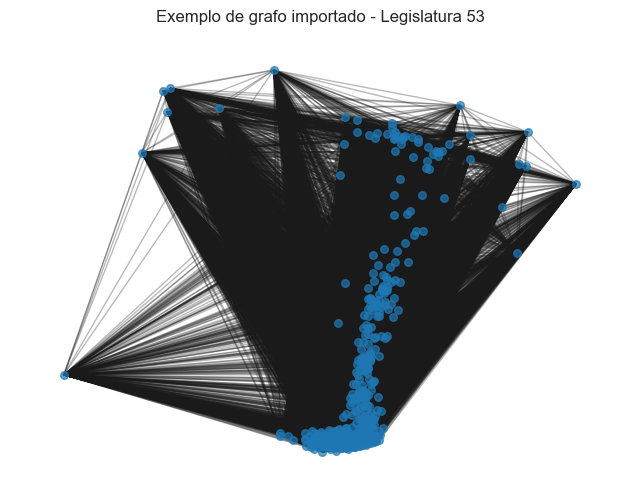

,Número de nós,Número de arestas,Atributos do grafo,"Amostra de nós (id, atributos)","Amostra de arestas (id1, id2, atributos)"
0,598,178503,{'filename': 'graph_legislature_53_with_commun...,"[(129618, {'community': 0}), (131873, {'commun...","[(129618, 131873, {'weight': -0.5}), (129618, ..."


In [97]:
import matplotlib.pyplot as plt

# Selecionar uma legislatura para exemplo, por exemplo, 53
leg_exemplo = 53
G_exemplo = graphs_by_legislature[leg_exemplo]

# Visualização do grafo
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_exemplo, seed=42)  # layout para visualização
nx.draw_networkx_nodes(G_exemplo, pos, node_size=30, alpha=0.7)
nx.draw_networkx_edges(G_exemplo, pos, alpha=0.3)
plt.title(f"Exemplo de grafo importado - Legislatura {leg_exemplo}")
plt.axis('off')
plt.show()

# Exibir metadados do grafo exemplo em uma tabela
# Metadados típicos: número de nós, número de arestas, atributos do grafo, atributos dos nós, atributos das arestas

# Número de nós e arestas
num_nos = G_exemplo.number_of_nodes()
num_arestas = G_exemplo.number_of_edges()

# Atributos do grafo
atributos_grafo = dict(G_exemplo.graph)

# Atributos dos nós (exemplo: pegar os primeiros 3 nós e seus atributos)
amostra_nos = list(G_exemplo.nodes(data=True))[:3]

# Atributos das arestas (exemplo: pegar as primeiras 3 arestas e seus atributos)
amostra_arestas = list(G_exemplo.edges(data=True))[:3]

# Montar tabela de metadados
metadados = {
    "Número de nós": [num_nos],
    "Número de arestas": [num_arestas],
    "Atributos do grafo": [atributos_grafo],
    "Amostra de nós (id, atributos)": [amostra_nos],
    "Amostra de arestas (id1, id2, atributos)": [amostra_arestas]
}

metadados_df = pd.DataFrame(metadados)
display(metadados_df)


In [98]:
# Para cada linha do dataset unique_author_legislature, verificar se o idDeputadoAutor está presente como nó no grafo da legislatura ANTERIOR (L-1)

def check_deputado_in_previous_graph(row):
    leg = row['legislatura']
    dep_id = row['idDeputadoAutor']
    leg_anterior = leg - 1  # Legislatura anterior

    # Garantir que ambos são do mesmo tipo (int)
    try:
        dep_id_int = int(dep_id)
    except Exception as e:
        print(f"Erro ao converter dep_id {dep_id} para int: {e}")
        dep_id_int = dep_id  # fallback para valor original

    G_prev = graphs_by_legislature.get(leg_anterior)
    if G_prev is not None:
        # Pega todos os ids dos nós convertidos para int para garantir comparação correta
        node_ids = set()
        for n in G_prev.nodes:
            try:
                n_int = int(n)
            except Exception as e:
                print(f"Erro ao converter nó {n} para int: {e}")
                n_int = n
            node_ids.add(n_int)
        # Log para verificação
        print(f"Comparando dep_id: {dep_id_int} (original: {dep_id}) com ids dos nós da legislatura anterior {leg_anterior} (exemplo: {list(node_ids)[:5]})")
        return dep_id_int in node_ids
    else:
        print(f"Grafo não encontrado para legislatura anterior {leg_anterior}")
        return False

# Cria uma nova coluna 'presente_no_grafo_anterior' indicando se o deputado está presente no grafo da legislatura ANTERIOR
unique_author_legislature['presente_no_grafo_anterior'] = unique_author_legislature.apply(check_deputado_in_previous_graph, axis=1)

# Exibir as primeiras linhas para conferência
unique_author_legislature


Comparando dep_id: 74399 (original: 74399) com ids dos nós da legislatura anterior 52 (exemplo: [65551, 73761, 73764, 73765, 73768])
Comparando dep_id: 74517 (original: 74517) com ids dos nós da legislatura anterior 52 (exemplo: [65551, 73761, 73764, 73765, 73768])
Comparando dep_id: 74324 (original: 74324) com ids dos nós da legislatura anterior 52 (exemplo: [65551, 73761, 73764, 73765, 73768])
Comparando dep_id: 73982 (original: 73982) com ids dos nós da legislatura anterior 52 (exemplo: [65551, 73761, 73764, 73765, 73768])
Comparando dep_id: 73431 (original: 73431) com ids dos nós da legislatura anterior 52 (exemplo: [65551, 73761, 73764, 73765, 73768])
Comparando dep_id: 73666 (original: 73666) com ids dos nós da legislatura anterior 52 (exemplo: [65551, 73761, 73764, 73765, 73768])
Comparando dep_id: 74688 (original: 74688) com ids dos nós da legislatura anterior 52 (exemplo: [65551, 73761, 73764, 73765, 73768])
Comparando dep_id: 74862 (original: 74862) com ids dos nós da legisla

,idDeputadoAutor,legislatura,presente_no_grafo_anterior
0,74399,53,True
2,74517,53,True
4,74324,53,True
6,73982,53,True
7,73431,53,True
...,...,...,...
43092,141428,57,True
43093,141434,57,True
43094,73696,57,True
43098,74212,57,True


# Extração de Métricas de Rede para Deputados Autores

Nesta seção, vamos calcular métricas de ciências das redes para cada deputado autor, com base no grafo da legislatura anterior. Essas métricas nos ajudarão a entender a posição e influência de cada deputado na rede parlamentar.

Métricas que serão extraídas:
1. Centralidade de grau (Degree centrality)
2. Centralidade de proximidade (Closeness centrality)
3. Centralidade de autovetor (Eigenvector centrality)
4. Coeficiente de agrupamento (Clustering coefficient) 
5. PageRank
6. ID da comunidade (Community ID)

Nota: A métrica de Betweenness centrality foi removida devido ao seu alto custo computacional.


In [99]:
def extract_network_metrics(row, graph):
    """
    Extrai métricas de rede para um deputado específico de um grafo.
    
    Args:
        row: Linha do DataFrame com idDeputadoAutor e legislatura
        graph: Grafo NetworkX do qual extrair as métricas
    
    Returns:
        dict: Dicionário com as métricas de rede calculadas
    """
    # Utilizar a função auxiliar para encontrar o ID correto
    original_id = row['idDeputadoAutor']
    dep_id = find_deputy_id_in_graph(original_id, graph)
    
    if dep_id is None:
        # Retornar valores nulos para todas as métricas
        return {
            'degree_centrality': None,
            'closeness_centrality': None,
            'eigenvector_centrality': None,
            'clustering_coefficient': None,
            'pagerank': None,
            'community_id': None
        }
    
    # Calcular métricas
    metrics = {}
    
    try:
        # 1. Degree Centrality
        degree_dict = nx.degree_centrality(graph)
        if dep_id in degree_dict:
            metrics['degree_centrality'] = degree_dict[dep_id]
        else:
            metrics['degree_centrality'] = None
        
        # 2. Closeness Centrality
        try:
            # Verificar se há pesos negativos
            has_negative_weights = any(w < 0 for _, _, w in graph.edges(data='weight') if w is not None)
            
            if has_negative_weights:
                # Usar sem pesos se houver pesos negativos
                closeness_dict = nx.closeness_centrality(graph)
            else:
                closeness_dict = nx.closeness_centrality(graph, distance='weight')
                
            if dep_id in closeness_dict:
                metrics['closeness_centrality'] = closeness_dict[dep_id]
            else:
                metrics['closeness_centrality'] = None
        except:
            # Em caso de qualquer erro, tentar sem pesos
            try:
                closeness_dict = nx.closeness_centrality(graph)
                if dep_id in closeness_dict:
                    metrics['closeness_centrality'] = closeness_dict[dep_id]
                else:
                    metrics['closeness_centrality'] = None
            except:
                metrics['closeness_centrality'] = None
        
        # 3. Eigenvector Centrality
        try:
            eigenvector_dict = nx.eigenvector_centrality(graph, max_iter=300, weight='weight')
            if dep_id in eigenvector_dict:
                metrics['eigenvector_centrality'] = eigenvector_dict[dep_id]
            else:
                # Caso não funcione, tentar com algoritmo de potência
                try:
                    eigenvector_dict = nx.eigenvector_centrality_numpy(graph, weight='weight')
                    if dep_id in eigenvector_dict:
                        metrics['eigenvector_centrality'] = eigenvector_dict[dep_id]
                    else:
                        metrics['eigenvector_centrality'] = None
                except:
                    metrics['eigenvector_centrality'] = None
        except:
            metrics['eigenvector_centrality'] = None
        
        # 4. Clustering Coefficient
        try:
            # Usar com cuidado com os pesos - alguns algoritmos podem ter problemas com pesos negativos
            metrics['clustering_coefficient'] = nx.clustering(graph, dep_id, weight='weight')
        except:
            # Se falhar com pesos, tentar sem pesos
            try:
                metrics['clustering_coefficient'] = nx.clustering(graph, dep_id)
            except:
                metrics['clustering_coefficient'] = None
        
        # 5. PageRank
        try:
            # Tentar com parâmetros mais robustos
            pagerank_dict = nx.pagerank(graph, alpha=0.80, max_iter=500, weight='weight')
            if dep_id in pagerank_dict:
                metrics['pagerank'] = pagerank_dict[dep_id]
            else:
                metrics['pagerank'] = None
        except nx.PowerIterationFailedConvergence:
            try:
                # Segunda tentativa sem pesos e com alpha menor
                pagerank_dict = nx.pagerank(graph, alpha=0.75, max_iter=1000, weight=None)
                if dep_id in pagerank_dict:
                    metrics['pagerank'] = pagerank_dict[dep_id]
                else:
                    metrics['pagerank'] = None
            except:
                # Usar uma alternativa simples baseada em grau
                try:
                    dc = nx.degree_centrality(graph)
                    if dep_id in dc:
                        metrics['pagerank'] = dc[dep_id]  # Aproximação
                    else:
                        metrics['pagerank'] = None
                except:
                    metrics['pagerank'] = None
        
        # 6. Community ID (se estiver presente como atributo do nó)
        try:
            metrics['community_id'] = graph.nodes[dep_id].get('community', None)
        except:
            metrics['community_id'] = None
        
    except:
        pass  # Silenciar erros gerais
        
    return metrics


In [100]:
# Aplicando a extração de métricas para cada deputado/legislatura
import time
from tqdm import tqdm  # Usando tqdm padrão em vez de tqdm.notebook

# Criar cópia do DataFrame para não modificar o original
unique_author_legislature_with_metrics = unique_author_legislature.copy()

# Inicializar as colunas de métricas com None
metrics_columns = [
    'degree_centrality', 'closeness_centrality',
    'eigenvector_centrality', 'clustering_coefficient', 'pagerank', 'community_id'
]

for col in metrics_columns:
    unique_author_legislature_with_metrics[col] = None

# Contagem total de deputados e legislaturas para processar
total_deputados = len(unique_author_legislature_with_metrics)
print(f"Total de deputados/legislaturas para processar: {total_deputados}")

# Para cada deputado/legislatura, extrair métricas do grafo da legislatura anterior
start_time = time.time()
print("Extraindo métricas de rede para cada deputado...")

# Pré-calcular métricas para todos os grafos para economizar tempo
print("Pré-calculando métricas globais para todos os grafos...")
precalculated_metrics = {}
for leg, graph in graphs_by_legislature.items():
    precalculated_metrics[leg] = {
        'degree_centrality': nx.degree_centrality(graph)
    }
    
    # Calcular PageRank com tratamento para falha de convergência
    try:
        print(f"Calculando PageRank para grafo da legislatura {leg}...")
        # Aumentar max_iter e ajustar alpha para ajudar na convergência
        precalculated_metrics[leg]['pagerank'] = nx.pagerank(graph, alpha=0.80, max_iter=500, weight='weight')
        print(f"  - PageRank calculado com sucesso.")
    except nx.PowerIterationFailedConvergence:
        print(f"  - PageRank não convergiu. Tentando com alpha menor e sem pesos...")
        try:
            # Tentar com alpha menor e sem considerar pesos
            precalculated_metrics[leg]['pagerank'] = nx.pagerank(graph, alpha=0.75, max_iter=1000, weight=None)
            print(f"  - PageRank calculado com sucesso na segunda tentativa.")
        except:
            print(f"  - Não foi possível calcular PageRank para o grafo {leg}. Usando algoritmo mais simples.")
            # Usar um algoritmo mais simples como fallback
            try:
                # Usar degree centrality normalizado como substituição para PageRank
                dc = nx.degree_centrality(graph)
                total = sum(dc.values())
                pr = {n: v/total for n, v in dc.items()}
                precalculated_metrics[leg]['pagerank'] = pr
                print(f"  - Substituição para PageRank criada com sucesso.")
            except:
                print(f"  - Todos os métodos para PageRank falharam. Usando dicionário vazio.")
                precalculated_metrics[leg]['pagerank'] = {}
    
    # Verificar se há pesos negativos nas arestas
    has_negative_weights = any(w < 0 for _, _, w in graph.edges(data='weight') if w is not None)
    
    # Para closeness_centrality, usar o algoritmo apropriado baseado nos pesos
    print(f"Calculando closeness centrality para grafo da legislatura {leg}...")
    if has_negative_weights:
        print(f"  - Grafo possui pesos negativos. Calculando closeness sem usar pesos.")
        precalculated_metrics[leg]['closeness_centrality'] = nx.closeness_centrality(graph)
    else:
        try:
            precalculated_metrics[leg]['closeness_centrality'] = nx.closeness_centrality(graph, distance='weight')
            print(f"  - Closeness centrality calculado com sucesso.")
        except ValueError:
            # Em caso de erro, tentar sem usar pesos
            print(f"  - Erro ao calcular closeness_centrality com pesos. Usando sem pesos.")
            precalculated_metrics[leg]['closeness_centrality'] = nx.closeness_centrality(graph)
    
    # Tentar calcular eigenvector centrality (que pode não convergir)
    print(f"Calculando eigenvector centrality para grafo da legislatura {leg}...")
    try:
        precalculated_metrics[leg]['eigenvector_centrality'] = nx.eigenvector_centrality(graph, max_iter=500, weight='weight')
        print(f"  - Eigenvector centrality calculado com sucesso.")
    except:
        print(f"  - Método padrão falhou. Tentando com método numpy...")
        try:
            precalculated_metrics[leg]['eigenvector_centrality'] = nx.eigenvector_centrality_numpy(graph, weight='weight')
            print(f"  - Eigenvector centrality (numpy) calculado com sucesso.")
        except:
            print(f"  - Não foi possível calcular eigenvector_centrality. Usando algoritmo mais simples.")
            try:
                # Usar degree centrality como substituição
                precalculated_metrics[leg]['eigenvector_centrality'] = nx.degree_centrality(graph)
                print(f"  - Substituição para eigenvector centrality criada com sucesso.")
            except:
                print(f"  - Todos os métodos falharam. Usando dicionário vazio.")
                precalculated_metrics[leg]['eigenvector_centrality'] = {}
            
print("\nMétricas globais pré-calculadas com sucesso.")

# Processa todos os deputados/legislaturas
for idx, row in tqdm(unique_author_legislature_with_metrics.iterrows(), total=total_deputados):
    leg = row['legislatura']
    leg_anterior = leg - 1  # Legislatura anterior
    
    # Verificar se existe grafo para a legislatura anterior
    if leg_anterior in graphs_by_legislature and leg_anterior in precalculated_metrics:
        # Obter o grafo da legislatura anterior
        G_prev = graphs_by_legislature[leg_anterior]
        
        # Tentar usar métricas pré-calculadas primeiro
        try:
            # Obter o ID do deputado no formato correto para o grafo
            dep_id = find_deputy_id_in_graph(row['idDeputadoAutor'], G_prev)
            if dep_id is not None:
                # Usar métricas pré-calculadas
                precalc = precalculated_metrics[leg_anterior]
                
                # Degree centrality
                if dep_id in precalc['degree_centrality']:
                    unique_author_legislature_with_metrics.at[idx, 'degree_centrality'] = precalc['degree_centrality'][dep_id]
                
                # Closeness centrality
                if dep_id in precalc['closeness_centrality']:
                    unique_author_legislature_with_metrics.at[idx, 'closeness_centrality'] = precalc['closeness_centrality'][dep_id]
                
                # Eigenvector centrality
                if 'eigenvector_centrality' in precalc and dep_id in precalc['eigenvector_centrality']:
                    unique_author_legislature_with_metrics.at[idx, 'eigenvector_centrality'] = precalc['eigenvector_centrality'][dep_id]
                
                # PageRank
                if dep_id in precalc['pagerank']:
                    unique_author_legislature_with_metrics.at[idx, 'pagerank'] = precalc['pagerank'][dep_id]
                
                # Clustering coefficient e community_id ainda precisam ser calculados individualmente
                try:
                    unique_author_legislature_with_metrics.at[idx, 'clustering_coefficient'] = nx.clustering(G_prev, dep_id, weight='weight')
                except:
                    try:
                        unique_author_legislature_with_metrics.at[idx, 'clustering_coefficient'] = nx.clustering(G_prev, dep_id)
                    except:
                        pass
                        
                try:
                    unique_author_legislature_with_metrics.at[idx, 'community_id'] = G_prev.nodes[dep_id].get('community', None)
                except:
                    pass
            else:
                # Se não conseguiu encontrar o ID, manter valores nulos
                pass
        except:
            # Em caso de erro, tentar com o método original
            try:
                metrics = extract_network_metrics(row, G_prev)
                for metric_name, metric_value in metrics.items():
                    if metric_name in metrics_columns:
                        unique_author_legislature_with_metrics.at[idx, metric_name] = metric_value
            except:
                pass  # Silenciosamente continuar em caso de erro

# Mostrar tempo total de processamento
elapsed_time = time.time() - start_time
print(f"Extração de métricas concluída em {elapsed_time:.2f} segundos.")

# Contagem de valores não nulos por métrica
non_null_counts = {col: unique_author_legislature_with_metrics[col].notna().sum() for col in metrics_columns}
print("\nContagem de valores não nulos por métrica:")
for col, count in non_null_counts.items():
    print(f"{col}: {count}/{total_deputados} ({count/total_deputados*100:.1f}%)")

# Exibir as primeiras linhas para verificação
print("\nPrimeiras 5 linhas do DataFrame:")
display(unique_author_legislature_with_metrics.head())


Total de deputados/legislaturas para processar: 1706
Extraindo métricas de rede para cada deputado...
Pré-calculando métricas globais para todos os grafos...
Calculando PageRank para grafo da legislatura 52...
  - PageRank calculado com sucesso.
Calculando closeness centrality para grafo da legislatura 52...
  - Grafo possui pesos negativos. Calculando closeness sem usar pesos.
Calculando eigenvector centrality para grafo da legislatura 52...
  - Eigenvector centrality calculado com sucesso.
Calculando PageRank para grafo da legislatura 53...
  - PageRank não convergiu. Tentando com alpha menor e sem pesos...
  - PageRank calculado com sucesso na segunda tentativa.
Calculando closeness centrality para grafo da legislatura 53...
  - Grafo possui pesos negativos. Calculando closeness sem usar pesos.
Calculando eigenvector centrality para grafo da legislatura 53...
  - Eigenvector centrality calculado com sucesso.
Calculando PageRank para grafo da legislatura 54...
  - PageRank não conver

100%|██████████| 1706/1706 [16:32<00:00,  1.72it/s]

Extração de métricas concluída em 1038.59 segundos.

Contagem de valores não nulos por métrica:
degree_centrality: 1706/1706 (100.0%)
closeness_centrality: 1706/1706 (100.0%)
eigenvector_centrality: 1706/1706 (100.0%)
clustering_coefficient: 1706/1706 (100.0%)
pagerank: 1706/1706 (100.0%)
community_id: 1706/1706 (100.0%)

Primeiras 5 linhas do DataFrame:


,idDeputadoAutor,legislatura,presente_no_grafo_anterior,degree_centrality,closeness_centrality,eigenvector_centrality,clustering_coefficient,pagerank,community_id
0,74399,53,True,1.0,1.0,0.007723,0.066571,0.000909,1
2,74517,53,True,1.0,1.0,0.04388,0.357156,0.001855,0
4,74324,53,True,1.0,1.0,0.039475,0.280483,0.001889,1
6,73982,53,True,1.0,1.0,0.055631,0.442722,0.002326,0
7,73431,53,True,1.0,1.0,0.00894,0.11218,0.001097,1


In [101]:
# Remover a coluna betweenness_centrality se ainda existir
if 'betweenness_centrality' in unique_author_legislature_with_metrics.columns:
    unique_author_legislature_with_metrics = unique_author_legislature_with_metrics.drop(columns=['betweenness_centrality'])

# Analisando os resultados - Contagem de valores nulos por métrica
null_counts = unique_author_legislature_with_metrics[metrics_columns].isnull().sum()
print("Contagem de valores nulos por métrica:")
print(null_counts)

# Percentual de valores não-nulos por métrica
total_rows = len(unique_author_legislature_with_metrics)
non_null_percentage = 100 - (null_counts / total_rows * 100)
print("\nPercentual de valores não-nulos por métrica:")
for col, pct in zip(metrics_columns, non_null_percentage):
    print(f"{col}: {pct:.2f}%")

# Estatísticas descritivas das métricas
print("\nEstatísticas descritivas das métricas:")
desc_stats = unique_author_legislature_with_metrics[metrics_columns].describe()
display(desc_stats)


Contagem de valores nulos por métrica:
degree_centrality         0
closeness_centrality      0
eigenvector_centrality    0
clustering_coefficient    0
pagerank                  0
community_id              0
dtype: int64

Percentual de valores não-nulos por métrica:
degree_centrality: 100.00%
closeness_centrality: 100.00%
eigenvector_centrality: 100.00%
clustering_coefficient: 100.00%
pagerank: 100.00%
community_id: 100.00%

Estatísticas descritivas das métricas:


,degree_centrality,closeness_centrality,eigenvector_centrality,clustering_coefficient,pagerank,community_id
count,1706.0,1706.0,1706.000000,1706,1706.000000,1706
unique,1.0,1.0,1696.000000,1701,744.000000,3
top,1.0,1.0,0.059998,0,0.001678,0
freq,1706.0,1706.0,3.000000,3,389.000000,1051


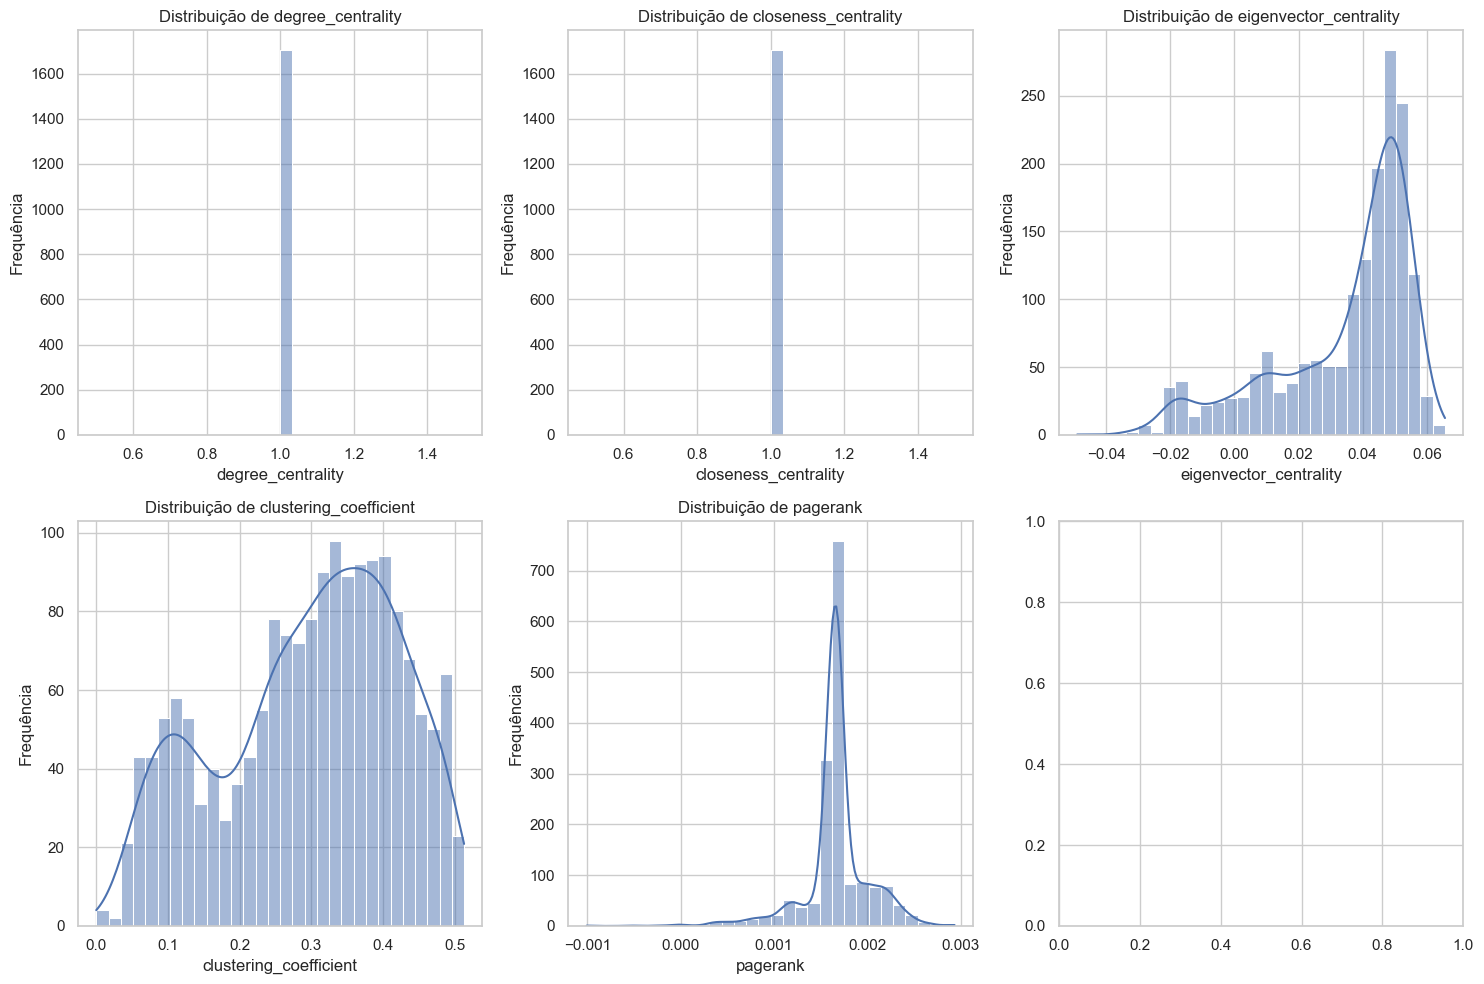

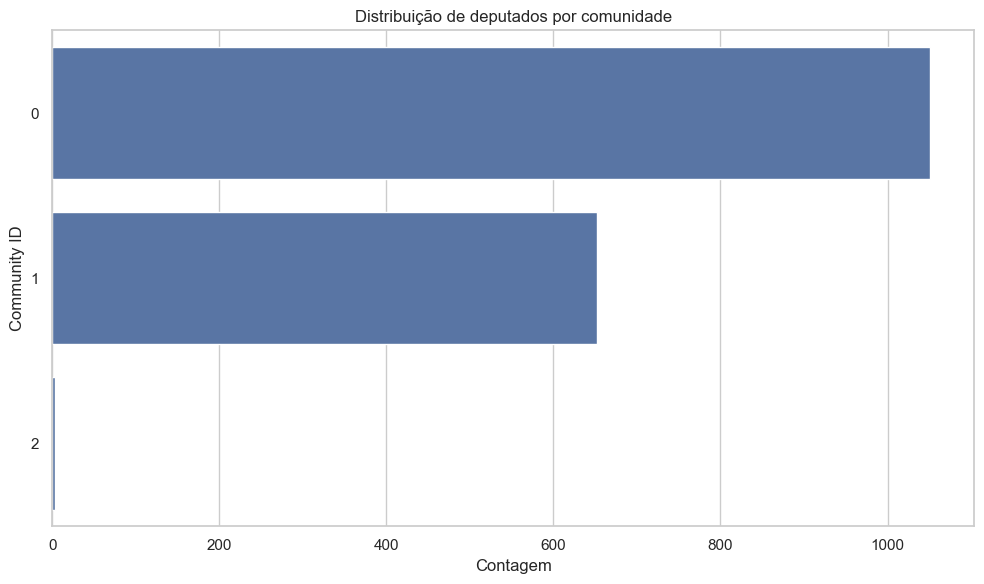

In [102]:
# Visualizar a distribuição das métricas
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar o estilo do Seaborn
sns.set(style="whitegrid")

# Criar figura com 6 subplots (excluindo community_id que é categórico)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Métricas numéricas para visualização
num_metrics = [col for col in metrics_columns if col != 'community_id']

# Plotar histogramas para cada métrica
for i, metric in enumerate(num_metrics):
    ax = axes[i]
    
    # Filtrar valores não nulos
    valid_data = unique_author_legislature_with_metrics[metric].dropna()
    
    if len(valid_data) > 0:
        sns.histplot(valid_data, ax=ax, kde=True, bins=30)
        ax.set_title(f'Distribuição de {metric}')
        ax.set_xlabel(metric)
        ax.set_ylabel('Frequência')
    else:
        ax.text(0.5, 0.5, "Sem dados disponíveis", 
                horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes)

plt.tight_layout()
plt.show()

# Para a comunidade (variável categórica), criar um countplot separado
if not unique_author_legislature_with_metrics['community_id'].isnull().all():
    plt.figure(figsize=(10, 6))
    # Usar método alternativo caso o countplot padrão falhe
    try:
        sns.countplot(y='community_id', 
                      data=unique_author_legislature_with_metrics,
                      order=unique_author_legislature_with_metrics['community_id'].value_counts().index)
    except:
        # Alternativa usando matplotlib diretamente
        counts = unique_author_legislature_with_metrics['community_id'].value_counts()
        plt.barh(y=counts.index.astype(str), width=counts.values)
    
    plt.title('Distribuição de deputados por comunidade')
    plt.xlabel('Contagem')
    plt.ylabel('Community ID')
    plt.tight_layout()
    plt.show()


In [103]:
# Salvar o DataFrame com as métricas de rede
unique_author_legislature_with_metrics.to_csv("deputados_metricas_rede.csv", index=False)
print("DataFrame com métricas de rede salvo como 'deputados_metricas_rede.csv'")

# Também podemos salvar uma versão que será usada para combinar com os dados de votação
# Esta versão terá uma chave de junção adequada
unique_author_legislature_with_metrics_for_merge = unique_author_legislature_with_metrics.copy()
unique_author_legislature_with_metrics_for_merge.rename(columns={
    'idDeputadoAutor': 'idDeputado',
    'degree_centrality': 'autor_degree_centrality',
    'closeness_centrality': 'autor_closeness_centrality',
    'eigenvector_centrality': 'autor_eigenvector_centrality',
    'clustering_coefficient': 'autor_clustering_coefficient',
    'pagerank': 'autor_pagerank',
    'community_id': 'autor_community_id'
}, inplace=True)

unique_author_legislature_with_metrics_for_merge.to_csv("deputados_metricas_rede_para_merge.csv", index=False)
print("DataFrame preparado para merge salvo como 'deputados_metricas_rede_para_merge.csv'")

# Mostrar o DataFrame pronto para merge
unique_author_legislature_with_metrics_for_merge.tail()


DataFrame com métricas de rede salvo como 'deputados_metricas_rede.csv'
DataFrame preparado para merge salvo como 'deputados_metricas_rede_para_merge.csv'


,idDeputado,legislatura,presente_no_grafo_anterior,autor_degree_centrality,autor_closeness_centrality,autor_eigenvector_centrality,autor_clustering_coefficient,autor_pagerank,autor_community_id
43092,141428,57,True,1.0,1.0,0.043256,0.344143,0.001678,0
43093,141434,57,True,1.0,1.0,0.050113,0.474788,0.001678,0
43094,73696,57,True,1.0,1.0,0.045211,0.447186,0.001678,0
43098,74212,57,True,1.0,1.0,0.046091,0.405806,0.001678,0
43112,141431,57,True,1.0,1.0,0.05078,0.483228,0.001678,0


In [104]:
# Contar quantos deputados foram encontrados vs não encontrados no grafo
contagem_presenca = unique_author_legislature['presente_no_grafo_anterior'].value_counts()
print("Contagem de deputados presentes vs não presentes no grafo:")
print(contagem_presenca)

# Exibir de forma mais amigável
encontrados = contagem_presenca.get(True, 0)
nao_encontrados = contagem_presenca.get(False, 0)
print(f"\nDeputados encontrados no grafo: {encontrados}")
print(f"Deputados NÃO encontrados no grafo: {nao_encontrados}")


Contagem de deputados presentes vs não presentes no grafo:
presente_no_grafo_anterior
True    1706
Name: count, dtype: int64

Deputados encontrados no grafo: 1706
Deputados NÃO encontrados no grafo: 0


In [105]:
# Realizar o merge para incluir as métricas de rede no dataset de votações
votacoes_selected_df = votacoes_selected_df.merge(
    unique_author_legislature_with_metrics_for_merge[
        ['idDeputado', 'legislatura', 'autor_eigenvector_centrality', 'autor_clustering_coefficient', 'autor_pagerank', 'autor_community_id']
    ],
    left_on=['idDeputadoAutor', 'legislatura'],
    right_on=['idDeputado', 'legislatura'],
    how='left'
)

# Opcional: remover a coluna 'idDeputado' extra após o merge, se não for necessária
votacoes_selected_df.drop(columns=['idDeputado'], inplace=True)

# Exibir as últimas linhas para conferência
votacoes_selected_df.tail()


,id,idDeputadoAutor,legislatura,data,tema,classified_llm,authors_pop,authors_major_comm,orientacao_GOV,aprovacao,autor_eigenvector_centrality,autor_clustering_coefficient,autor_pagerank,autor_community_id
43394,347421-215,74165,57,2024-12-19,Finanças Públicas e Orçamento,no_class,0.0,1,Neutro,1,0.051185,0.467471,0.001678,0
43395,347421-215,141372,57,2024-12-19,Finanças Públicas e Orçamento,no_class,0.0,1,Neutro,1,0.051288,0.468488,0.001678,0
43396,347421-215,74254,57,2024-12-19,Finanças Públicas e Orçamento,no_class,0.0,1,Neutro,1,0.045476,0.387322,0.001678,0
43397,347421-215,73808,57,2024-12-19,Finanças Públicas e Orçamento,no_class,0.0,1,Neutro,1,0.051143,0.49232,0.001678,0
43398,2473375-80,160674,57,2024-12-19,Previdência e Assistência Social,Approval of Final Wording,0.0,1,Neutro,1,0.050778,0.48419,0.001678,0


In [106]:
votacoes_selected_df.to_csv("votacoes_network.csv", index=False)
print("Arquivo 'votacoes_network.csv' salvo com sucesso.")


Arquivo 'votacoes_network.csv' salvo com sucesso.
